# Fine tune with Efficientnet

In [1]:
#!pip install keras-cv==0.4.2

In [2]:
import os, pathlib
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
from datetime import datetime
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel as ConfigBaseModel
import tensorflow as tf
print("tensorflow:", tf.__version__)
import keras_cv
print("keras_cv:", keras_cv.__version__)
import tensorflow_io as tfio
print("tfio:", tfio.__version__)
from sklearn.model_selection import train_test_split

tensorflow: 2.18.0


/Users/camcortes/Library/Caches/pypoetry/virtualenvs/birds-sounds-images-gIa9Kkaf-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


keras_cv: 0.9.0
tfio: 0.37.1


In [3]:
strategy = tf.distribute.MirroredStrategy()
print("Strategy:", strategy)
print("Number of replicas:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Strategy: <tensorflow.python.distribute.mirrored_strategy.MirroredStrategy object at 0x178ae8650>
Number of replicas: 1


In [4]:
sorted(tf.config.list_logical_devices())

[LogicalDevice(name='/device:CPU:0', device_type='CPU')]

# Config

In [5]:
from typing import Tuple
from pydantic import BaseModel

class Config(BaseModel):
    ## general
    run_ts: str = datetime.now().strftime("%Y-%d-%m %H:%M:%S")
    debug: bool = False
    model_name: str = "transfer_learn_simple"
    test_size: float = 0.2
    seed: int = 887
    fit_verbose: int = 1 if (os.environ.get('KAGGLE_KERNEL_RUN_TYPE') == "Interactive") else 2

    ## data
    dataset_dir: str = "./data_spec/train_spectograms.csv"
    path_data: str = "./data_spec/train_spectograms.csv"
    label: str = "label"
    n_label: int = 37
    img_size: Tuple[int, int] = (128, 256)
    channels: int = 1
    img_shape: Tuple[int, int, int] = (*img_size, channels)

    ## model
    base_model_weights: str = "imagenet"
    dropout: float = 0.20

    ## training
    label_smoothing: float = 0.05
    shuffle_size: int = 1028
    steps_per_epoch: int = 300
    batch_size: int = 128  # 16 * strategy.num_replicas_in_sync
    valid_batch_size: int = batch_size
    epochs: int = 80
    patience: int = 4
    monitor: str = "val_loss"  # val_loss
    monitor_mode: str = "auto"
    lr: float = 1e-4

    ## aug
    aug_proba: float = 0.8

# Crear una instancia de la configuración
cfg = Config()
cfg.dict()

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_4568/2293403790.py:43: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  cfg.dict()


{'run_ts': '2025-16-01 10:48:00',
 'debug': False,
 'model_name': 'transfer_learn_simple',
 'test_size': 0.2,
 'seed': 887,
 'fit_verbose': 2,
 'dataset_dir': './data_spec/train_spectograms.csv',
 'path_data': './data_spec/train_spectograms.csv',
 'label': 'label',
 'n_label': 37,
 'img_size': (128, 256),
 'channels': 1,
 'img_shape': (128, 256, 1),
 'base_model_weights': 'imagenet',
 'dropout': 0.2,
 'label_smoothing': 0.05,
 'shuffle_size': 1028,
 'steps_per_epoch': 300,
 'batch_size': 128,
 'valid_batch_size': 128,
 'epochs': 80,
 'patience': 4,
 'monitor': 'val_loss',
 'monitor_mode': 'auto',
 'lr': 0.0001,
 'aug_proba': 0.8}

# Preparation

## Load data

In [6]:
data = pd.read_csv(cfg.path_data)
data["path_img"] = data["image_path"]
if cfg.debug:
    data = data.iloc[:1000]
data.sample(6)
data.shape

(33729, 4)

## Dataset

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def show_img_stats(img):
    if isinstance(img, tf.Tensor):
        print((img.shape, img.dtype, img.numpy().min(), img.numpy().max()))
    elif isinstance(img, np.array):
        print((img.shape, img.dtype, img.min(), img.max()))
    else:
        print(f"unexpected type: {type(img)}")


def read_image(path_img):
    img_data = tf.io.read_file(path_img)
    img = tf.io.decode_jpeg(img_data, channels=cfg.channels)
    # Redimensionar la imagen a las dimensiones deseadas
    img = tf.image.resize(img, cfg.img_size)
    img = tf.cast(img, tf.float32)
    return img


from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(data.label)

def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=cfg.n_label)

In [8]:
import tensorflow as tf
import tensorflow_io as tfio
from keras_cv.layers import BaseImageAugmentationLayer

class RandomRowMask(keras_cv.layers.BaseImageAugmentationLayer):
    def __init__(self, param=10, max_num_mask=3, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    def augment_image(self, image, transformation=None, **kwargs):
        num = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)
        
        def condition(i, img):
            return tf.less(i, num)
        
        def body(i, img):
            img = tfio.audio.time_mask(tf.squeeze(img), param=self.param)
            img = tf.reshape(img, cfg.img_shape)
            return tf.add(i, 1), img
        
        _, image = tf.while_loop(
            condition,
            body,
            loop_vars=[0, image],
            shape_invariants=[tf.TensorShape([]), tf.TensorShape(cfg.img_shape)]
        )
        
        return image

class RandomColumnMask(keras_cv.layers.BaseImageAugmentationLayer):
    def __init__(self, param=40, max_num_mask=2, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    def augment_image(self, image, transformation=None, **kwargs):
        num = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)
        
        def condition(i, img):
            return tf.less(i, num)
        
        def body(i, img):
            img = tfio.audio.freq_mask(tf.squeeze(img), param=self.param)
            img = tf.reshape(img, cfg.img_shape)
            return tf.add(i, 1), img
        
        _, image = tf.while_loop(
            condition,
            body,
            loop_vars=[0, image],
            shape_invariants=[tf.TensorShape([]), tf.TensorShape(cfg.img_shape)]
        )
        
        return image
    

augmenter = keras_cv.layers.Augmenter(
    layers=[
        keras_cv.layers.RandomBrightness(factor=0.2),
        #keras_cv.layers.RandomContrast(factor=0.2),
        keras_cv.layers.GridMask(ratio_factor=(0.05, 0.10)),
        keras_cv.layers.RandomGaussianBlur(kernel_size=2, factor=0.1),
        RandomRowMask(10, 3),
        RandomColumnMask(40, 2)
    ]
)

def augment_image(img):
    if tf.random.uniform([]) <= cfg.aug_proba:
        img = augmenter(img)
    return img

In [9]:
def create_dataset(data, include_label=True, repeat=False, shuffle=False, augment=False, prefetch=False, batch_size=None):
    slices = data["path_img"].values
    read_func = read_image
    aug_func = augment_image
    if include_label:
        slices = slices, decode_label(data[cfg.label].values)
        read_func = lambda path_img, label: (read_image(path_img), label)
        aug_func = lambda img, label: (augment_image(img), label)
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(read_func, num_parallel_calls=AUTOTUNE)
    if repeat: ds = ds.repeat()
    if shuffle: ds = ds.shuffle(buffer_size=cfg.shuffle_size)
    if augment: ds = ds.map(aug_func, num_parallel_calls=AUTOTUNE)
    if batch_size: ds = ds.batch(batch_size)
    if prefetch: ds = ds.prefetch(AUTOTUNE)
    return ds

In [10]:
def create_training_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=True,
        shuffle=True,
        augment=True,
        prefetch=True,
        batch_size=cfg.batch_size,
    )

def create_validation_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=False,
        shuffle=False,
        augment=False,
        prefetch=True,
        batch_size=cfg.valid_batch_size,
    )

#### Check augmentation

In [11]:
rec = data.sample(1).iloc[0]
rec

label                                   Pheugopedius mystacalis
image_path    ./images_spectograms/val/Pheugopedius mystacal...
db                                                          val
path_img      ./images_spectograms/val/Pheugopedius mystacal...
Name: 30623, dtype: object

(TensorShape([128, 256, 1]), tf.float32, np.float32(4.0), np.float32(254.9414))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(247.4114))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(244.40393))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(212.51651))


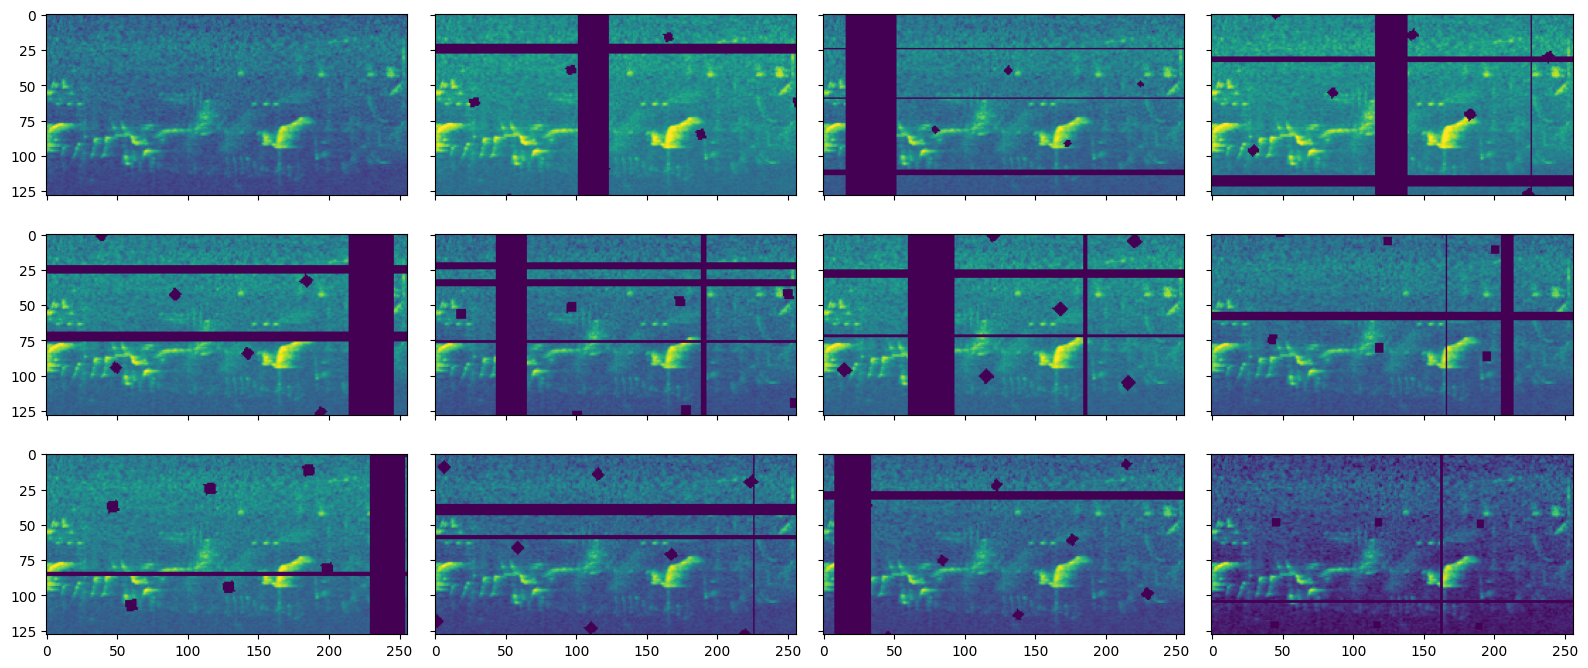

In [12]:
img = read_image(rec.image_path)
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 7))
for i, ax in enumerate(axs.flat):
    if i == 0:
        ax.imshow(img, cmap='viridis')
        show_img_stats(img)
    else:
        img1 = augmenter(img)
        ax.imshow(img1, cmap='viridis')
        show_img_stats(img1)
plt.tight_layout()
plt.show()   

#### Check dataset

In [13]:
dev_data = data.sample(500)
dev_ds = create_training_dataset(dev_data)
dev_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 37), dtype=tf.float32, name=None))>

In [14]:
elem = next(iter(dev_ds.take(1)))
elem[1]

<tf.Tensor: shape=(128, 37), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

(TensorShape([128, 256, 1]), tf.float32, np.float32(6.5742188), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(198.69379))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(228.23944))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.59765625), np.float32(250.14453))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(254.43718))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(1.1601562), np.float32(252.61719))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(255.0))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(228.87256))
(TensorShape([128, 256, 1]), tf.float32, np.float32(0.0), np.float32(241.50781))


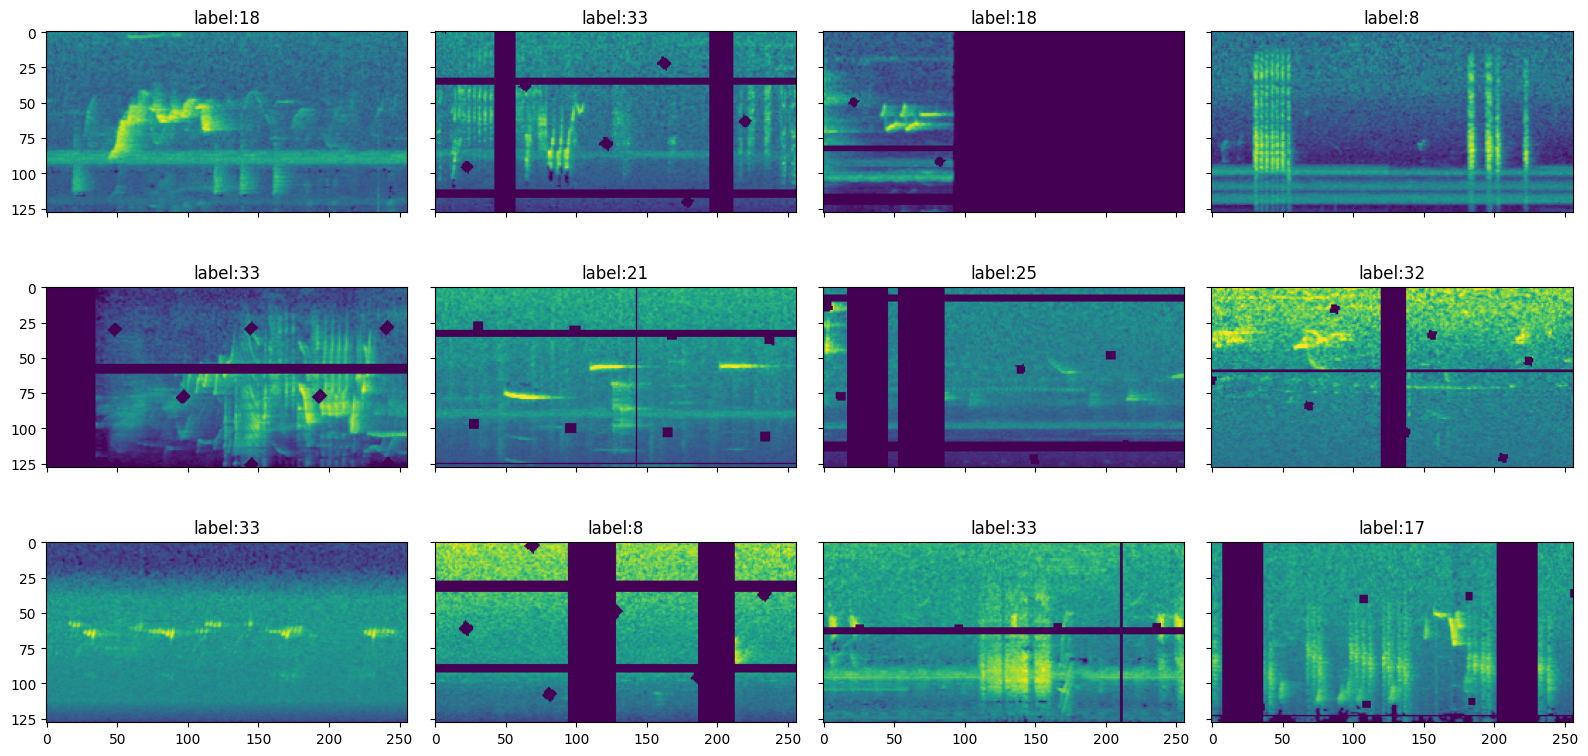

In [15]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 8))
for i, ax in enumerate(axs.flat):
    img = elem[0][i]
    show_img_stats(img)
    ax.imshow(img, cmap="viridis")
    ax.set_title(f"label:{np.argmax(elem[1][i].numpy())}")
plt.tight_layout()
plt.show()

# Neural network

In [16]:
from tensorflow.keras.applications.efficientnet import EfficientNetB7 as BaseModel
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, losses, metrics, callbacks

In [17]:
def create_model(lr):
    inputs = layers.Input(shape=cfg.img_shape, dtype=tf.float32)
    x = layers.Lambda(lambda img: tf.image.grayscale_to_rgb(img))(inputs)
    x = layers.Lambda(preprocess_input, name="preprocess_input")(x)
    base_model = BaseModel(include_top=False, weights=cfg.base_model_weights, pooling="avg")
    base_model.trainable = True
    fine_tune_at = 200  # Specify the number of layers to fine-tune
    for layer in base_model.layers[:-fine_tune_at]:
        layer.trainable = False
    x = base_model(x)
    #x = base_model(x, training=False)
    x = layers.Dropout(cfg.dropout, name="top_dropout")(x)
    outputs = layers.Dense(cfg.n_label, name="logits")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=cfg.model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=cfg.label_smoothing),
        metrics=['acc']
    )
    return model

#### Check model

In [18]:
tf.keras.backend.clear_session()
with strategy.scope():
    dev_model = create_model(lr=cfg.lr)
dev_model.summary(line_length=120)

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 32s 0us/step


Model: "transfer_learn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_layer (InputLayer)                            │ (None, 128, 256, 1)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lambda (Lambda)                                     │ (None, 128, 256, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ preprocess_input (Lambda)                           │ (None, 128, 256, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ efficientnetb7 (Functional)                         │ (None, 2560)                           │            64,097,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ top_dropout (Dropout)                               │ (None, 2560)                           │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ logits (Dense)                                      │ (None, 37)                             │                94,
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 64,192,444 (244.87 MB)

 Trainable params: 43,708,357 (166.73 MB)

 Non-trainable params: 20,484,087 (78.14 MB)

In [19]:
dev_model.predict(dev_ds.take(1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


array([[-0.39960545, -0.41037774,  0.41534442, ...,  0.05666512,
         0.23170592,  0.18377735],
       [-0.21247521, -0.37470764,  0.4358167 , ...,  0.15503037,
        -0.01648751, -0.08374017],
       [-0.39362884, -0.12547198,  0.510221  , ...,  0.3528713 ,
         0.78630686, -0.45525798],
       ...,
       [-0.11218685,  0.04854581, -0.01547351, ...,  0.13387968,
         0.1975066 , -0.4811767 ],
       [-0.06450667, -0.03645191,  0.2051077 , ...,  0.32537526,
         0.19802332, -0.4687695 ],
       [-0.5747189 , -0.31082064,  0.46031344, ...,  0.11026692,
         0.11707085, -0.32279617]], dtype=float32)

In [20]:
dev_model.evaluate(dev_ds.take(1), return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - acc: 0.0312 - loss: 0.6850


{'acc': 0.03125, 'loss': 0.685016393661499}

# Training utils

In [21]:
def get_callbacks(filepath):
    """Get callbacks"""
    cbs = [
        callbacks.ModelCheckpoint(
            filepath=filepath,
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            save_best_only=True,
            save_weights_only=True            
        ),
        callbacks.EarlyStopping(
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            patience=cfg.patience,
            restore_best_weights=False,
        ),
    ]
    return cbs


def show_history(history):
    """Show history"""
    history_frame = pd.DataFrame(history.history)
    history_frame.index = pd.RangeIndex(1, len(history_frame) + 1, name="epoch")
    display(history_frame.style\
        .highlight_min(color='lightgreen', subset=['val_loss'])\
        .highlight_max(color='lightgreen', subset=['val_acc'])
    )
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    history_frame.loc[:, ['loss', 'val_loss']].plot(ax=ax[0], title='loss')
    history_frame.loc[:, ['acc', 'val_acc']].plot(ax=ax[1], title='acc')
    plt.tight_layout()
    plt.show()
    
    
def compute_oof(model, valid_df):
    """Compute OOF"""
    valid_ds = create_validation_dataset(valid_df)
    oof_pred = model.predict(valid_ds, verbose=False)
    oof_pred = pd.DataFrame(tf.nn.sigmoid(oof_pred).numpy(), index=valid_df.index)
    oof = pd.concat({"y_true": valid_df[cfg.label], "y_pred": oof_pred}, axis=1)
    return oof    

In [27]:
def run_training(train_df, valid_df, model_name):
    """Run training"""
    # prepare dataset
    train_ds = create_training_dataset(train_df)
    valid_ds = create_validation_dataset(valid_df)
    # create model
    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_model(lr=cfg.lr)
  #  model.load_weights("/kaggle/input/fine-tune-60/weights_dev-b0-v8.h5")
    # fit
    steps_per_epoch = cfg.steps_per_epoch
    print("steps_per_epoch:", steps_per_epoch)
    path_weight = f"./model/weights_{model_name}.weights.h5"
    print("path_weights:", path_weight)
    hist = model.fit(
        train_ds,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_ds,
        callbacks=get_callbacks(path_weight),
        verbose=cfg.fit_verbose
    )
    # restore
    model.load_weights(path_weight)
#     # save full model
#     does not work: https://github.com/keras-team/keras/pull/17498 
#     path_model = f"/kaggle/working/{model_name}"
#     print("path_model:", path_model)
#     model.save(path_model)
    # compute oof
    oof = compute_oof(model, valid_df)
    return hist, oof,model

# Run training
Let us start by training just a single split.

In [28]:
train_df, valid_df = train_test_split(data, test_size=cfg.test_size, stratify=data[cfg.label])
valid_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df[cfg.label])
print(f"Split: {len(train_df)} vs {len(valid_df)} vs {len(test_df)}")
model_name = f"{cfg.model_name}"
print(f"model_name: {model_name}")

Split: 26983 vs 3373 vs 3373
model_name: transfer_learn_simple


In [29]:
hist, oof,model = run_training(train_df, valid_df, model_name)

steps_per_epoch: 300
path_weights: ./model/weights_transfer_learn_simple.weights.h5
Epoch 1/80

Epoch 1: val_loss improved from inf to 0.16976, saving model to ./model/weights_transfer_learn_simple.weights.h5
300/300 - 3557s - 12s/step - acc: 0.3237 - loss: 0.2356 - val_acc: 0.5360 - val_loss: 0.1698
Epoch 2/80

Epoch 2: val_loss improved from 0.16976 to 0.15341, saving model to ./model/weights_transfer_learn_simple.weights.h5
300/300 - 3367s - 11s/step - acc: 0.5338 - loss: 0.1644 - val_acc: 0.6588 - val_loss: 0.1534
Epoch 3/80

Epoch 3: val_loss improved from 0.15341 to 0.14753, saving model to ./model/weights_transfer_learn_simple.weights.h5
300/300 - 3227s - 11s/step - acc: 0.6303 - loss: 0.1557 - val_acc: 0.7290 - val_loss: 0.1475
Epoch 4/80

Epoch 4: val_loss improved from 0.14753 to 0.14269, saving model to ./model/weights_transfer_learn_simple.weights.h5
300/300 - 3019s - 10s/step - acc: 0.6857 - loss: 0.1505 - val_acc: 0.7637 - val_loss: 0.1427
Epoch 5/80

Epoch 5: val_loss im

,acc,loss,val_acc,val_loss
epoch,,,,
1,0.323750,0.235580,0.536021,0.169764
2,0.533828,0.164428,0.658761,0.153406
3,0.630313,0.155734,0.729025,0.147529
4,0.685677,0.150518,0.763712,0.142689
5,0.730937,0.146266,0.796620,0.140463
6,0.761172,0.143258,0.816484,0.137899
7,0.785130,0.140847,0.828936,0.136114
8,0.804714,0.138950,0.848206,0.134895
9,0.824427,0.136868,0.854136,0.133544


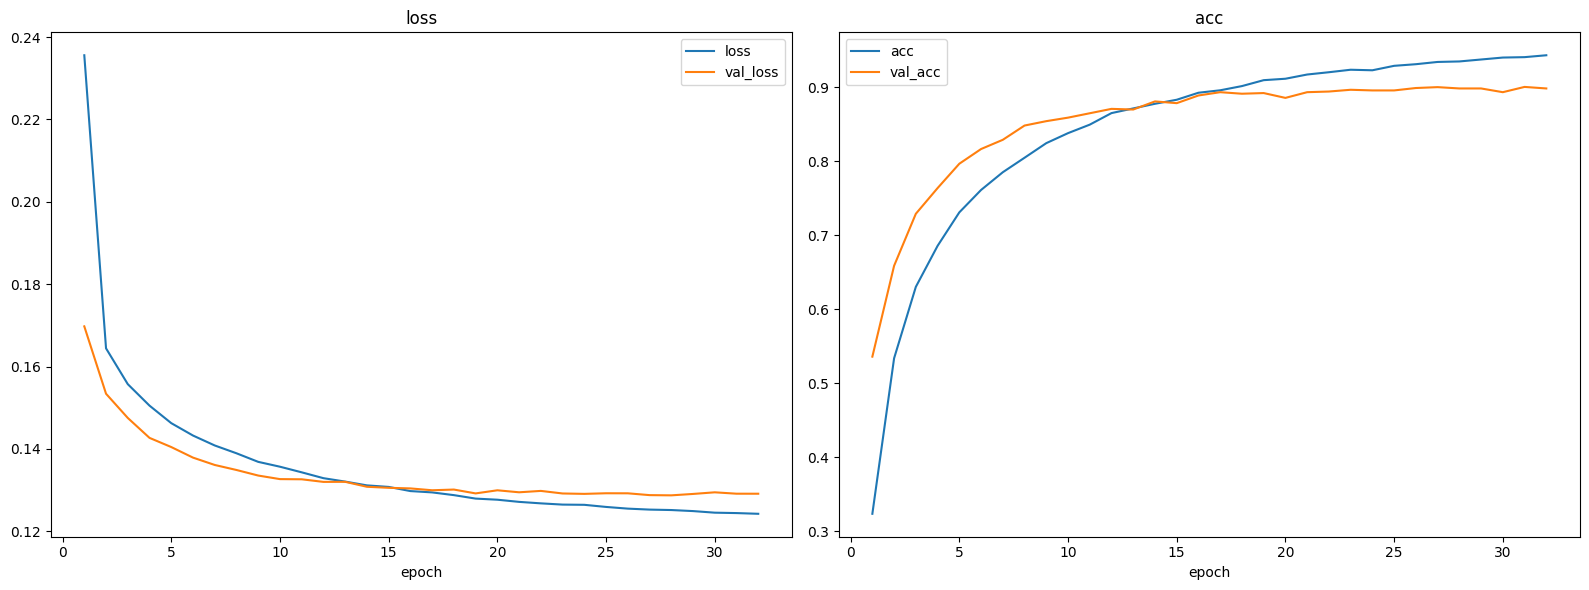

In [31]:
show_history(hist)

In [32]:
oof.to_csv("./model/transfer_learn_simple.csv")

# Evaluation

In [33]:
test_ds = create_validation_dataset(test_df)

In [34]:
true_labels = []
i=0
test_ds_size = test_ds.cardinality().numpy()
print(test_ds_size)
for batch in test_ds:
    _, batch_labels = batch  # assuming that labels are the second element of the batch tuple
    true_labels.extend(batch_labels.numpy().tolist())
    i+=1

27


In [36]:
pred_labels = model.predict(test_ds, verbose=cfg.fit_verbose)

27/27 - 114s - 4s/step


In [37]:
from sklearn.metrics import average_precision_score
mAP_score = average_precision_score(true_labels, pred_labels, average='macro')
average_precision = average_precision_score(true_labels, pred_labels)
print("Average Precision ", average_precision)
print("Macro average precision", mAP_score)

Average Precision  0.9216269979608721
Macro average precision 0.9216269979608721


In [38]:
from sklearn.metrics import accuracy_score
true_label = np.array(true_labels)
true_label = np.argmax(true_labels, axis=1)

pred_label=tf.argmax(pred_labels, axis=1).numpy()
# # assume y_true and y_pred are your true and predicted labels, respectively
acc = accuracy_score(true_label, pred_label)
print(acc)

0.9009783575452119


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
precision = precision_score(true_label, pred_label, average='macro')
recall = recall_score(true_label, pred_label,  average='macro')
f1_score = f1_score(true_label, pred_label, average='macro')

print("Precision: ", precision)
print("Recall: ", recall)
print("F1_score: ", f1_score)

true_label_str = label_encoder.inverse_transform(true_label)
pred_label_str = label_encoder.inverse_transform(pred_label)

# classification_report
print(classification_report(true_label_str, pred_label_str))

Precision:  0.8961590744320542
Recall:  0.8566983300470051
F1_score:  0.8741200587460417
                              precision    recall  f1-score   support

Campylorhynchus albobrunneus       1.00      0.91      0.95        11
     Campylorhynchus griseus       0.79      0.75      0.77        20
    Campylorhynchus nuchalis       0.86      0.67      0.75         9
    Campylorhynchus turdinus       0.76      0.70      0.73        60
     Campylorhynchus zonatus       0.97      0.81      0.88        37
        Cantorchilus griseus       0.70      0.70      0.70        10
     Cantorchilus leucopogon       0.82      0.75      0.78        24
       Cantorchilus leucotis       0.89      0.90      0.89       145
  Cantorchilus nigricapillus       0.89      0.90      0.90       186
     Cinnycerthia olivascens       0.89      0.85      0.87        65
        Cinnycerthia unirufa       0.88      0.81      0.84        26
       Cistothorus apolinari       0.92      0.98      0.95        50
